In [2]:
!pip uninstall streamlit -y

!pip install numpy==1.26.4

Found existing installation: streamlit 1.50.0
Uninstalling streamlit-1.50.0:
  Successfully uninstalled streamlit-1.50.0


In [1]:
import random
import numpy as np
from collections import defaultdict


In [5]:
class TrafficEnv:
    def __init__(self):
        self.lanes = [
            "N_left", "N_straight",
            "S_left", "S_straight",
            "E_left", "E_straight",
            "W_left", "W_straight"
        ]
        self.max_queue = 20
        self.phase = 0
        self.min_green_steps = 5
        self.phase_timer = 0
        self.Q_lanes = {}
        self.W = {}

    def reset(self):
        self.Q_lanes = {lane: random.randint(0, 3) for lane in self.lanes}
        self.W = {lane: 0 for lane in self.lanes}
        self.phase = random.randint(0, 3)
        return self.get_state()

    def discretize(self, q):
        if q <= 4:   return 0
        elif q <= 9: return 1
        elif q <= 14: return 2
        else:         return 3  

    def get_state(self):
        state = [self.discretize(self.Q_lanes[lane]) for lane in self.lanes]
        state.append(self.phase)
        return tuple(state)

    def apply_yellow(self):
        for lane in self.lanes:
        # No cars move during yellow (simplification)
            self.W[lane] += 1

    def step(self, action):
        
        if self.phase_timer < self.min_green_steps:
            action = self.phase   # override action, stay in current phase
            self.phase_timer += 1
        else:
            if action != self.phase:
                self.phase_timer = 0   # reset timer on switch
                self.apply_yellow()
            else:
                self.phase_timer += 1


        # if action != self.phase:
        #     for lane in self.lanes:
        #         self.W[lane] += 2  # yellow delay

        
        active_map = {
            0: ["N_straight", "S_straight"],
            1: ["N_left", "S_left"],
            2: ["E_straight", "W_straight"],
            3: ["E_left", "W_left"]
        }
        active = active_map[action]

        
        for lane in self.lanes:
            if lane in active:
                passed = min(5, self.Q_lanes[lane])
                self.Q_lanes[lane] -= passed
                self.W[lane] = max(0, self.W[lane] - passed)
            else:
                self.W[lane] += 1

        
        for lane in self.lanes:
            self.Q_lanes[lane] += random.randint(0, 1)  # was 0-2
            self.Q_lanes[lane] = min(self.Q_lanes[lane], self.max_queue)

        
        total_queue = sum(self.Q_lanes.values())
        total_wait = sum(self.W.values())
        reward = -(total_queue + 0.5 * total_wait) / (self.max_queue * len(self.lanes))

        self.phase = action
        return self.get_state(), reward



In [6]:
Q_table = defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])

alpha = 0.15          
gamma = 0.95          
epsilon = 1.0         
epsilon_decay = 0.998 
epsilon_min = 0.05

def choose_action(state, eps):
    if random.random() < eps:
        return random.randint(0, 3)
    return int(np.argmax(Q_table[state]))


In [7]:
env = TrafficEnv()
episodes = 6000
steps_per_episode = 200
rewards = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    for t in range(steps_per_episode):
        action = choose_action(state, epsilon)
        next_state, reward = env.step(action)

        # Q-learning update
        Q_table[state][action] += alpha * (
            reward + gamma * max(Q_table[next_state]) - Q_table[state][action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)  

    if ep % 50 == 0:
        window = min(50, len(rewards))
        avg = sum(rewards[-window:]) / window
        print(f"Episode {ep:4d} | Avg Reward: {avg:7.2f} | Epsilon: {epsilon:.3f}")

Episode    0 | Avg Reward: -309.68 | Epsilon: 0.998
Episode   50 | Avg Reward: -309.16 | Epsilon: 0.903
Episode  100 | Avg Reward: -309.10 | Epsilon: 0.817
Episode  150 | Avg Reward: -306.86 | Epsilon: 0.739
Episode  200 | Avg Reward: -300.96 | Epsilon: 0.669
Episode  250 | Avg Reward: -298.80 | Epsilon: 0.605
Episode  300 | Avg Reward: -298.42 | Epsilon: 0.547
Episode  350 | Avg Reward: -294.87 | Epsilon: 0.495
Episode  400 | Avg Reward: -294.57 | Epsilon: 0.448
Episode  450 | Avg Reward: -296.48 | Epsilon: 0.405
Episode  500 | Avg Reward: -292.02 | Epsilon: 0.367
Episode  550 | Avg Reward: -292.05 | Epsilon: 0.332
Episode  600 | Avg Reward: -288.95 | Epsilon: 0.300
Episode  650 | Avg Reward: -289.97 | Epsilon: 0.272
Episode  700 | Avg Reward: -291.22 | Epsilon: 0.246
Episode  750 | Avg Reward: -289.40 | Epsilon: 0.222
Episode  800 | Avg Reward: -287.53 | Epsilon: 0.201
Episode  850 | Avg Reward: -288.23 | Epsilon: 0.182
Episode  900 | Avg Reward: -288.10 | Epsilon: 0.165
Episode  950

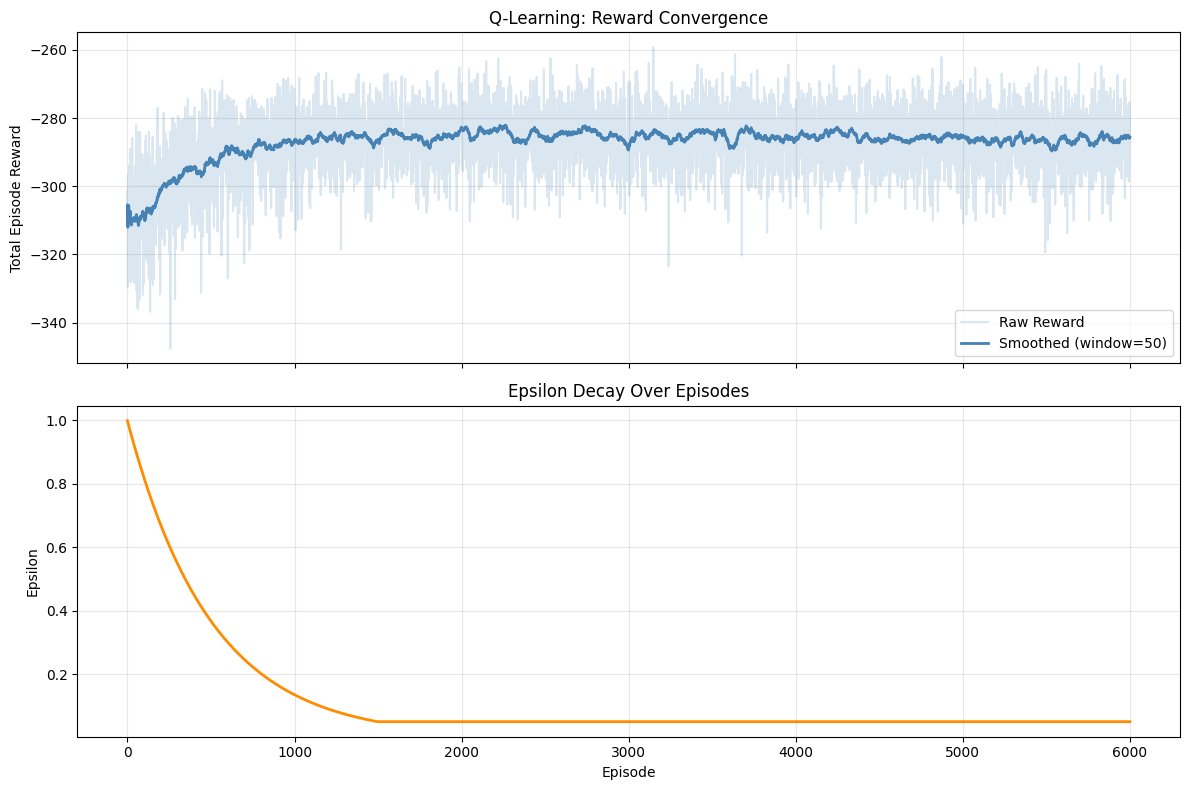

In [8]:
# ── Cell 1: Plot Rewards & Epsilon Decay ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def smooth(data, window=50):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

epsilons = []
eps = 1.0
for _ in range(6000):
    eps = max(0.05, eps * 0.998)
    epsilons.append(eps)

smoothed = smooth(rewards, window=50)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(rewards, alpha=0.2, color='steelblue', label='Raw Reward')
ax1.plot(smoothed, color='steelblue', linewidth=2, label='Smoothed (window=50)')
ax1.set_ylabel('Total Episode Reward')
ax1.set_title('Q-Learning: Reward Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epsilons, color='darkorange', linewidth=2)
ax2.set_ylabel('Epsilon')
ax2.set_xlabel('Episode')
ax2.set_title('Epsilon Decay Over Episodes')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ql_rewards_epsilon.png', dpi=150)
plt.show()

In [19]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
import torch
print(torch.cuda.is_available())

Using device: cpu
False


In [14]:
print(torch.__version__)

1.13.1+cpu


In [13]:
!nvidia-smi

Sun Apr 26 13:04:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   55C    P8              3W /   96W |    1856MiB /   8188MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import numpy as np

# --- Network ---
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)



class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states = zip(*batch)
        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states)
        )

    def __len__(self):
        return len(self.buffer)



class DQNAgent:
    def __init__(self, state_dim=9, action_dim=4):
        self.action_dim = action_dim
        self.policy_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=2e-4)
        self.buffer = ReplayBuffer(10000)
        self.batch_size = 64
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_decay = 0.998
        self.epsilon_min = 0.05
        self.update_target_every = 200
        self.steps = 0

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            q = self.policy_net(torch.FloatTensor(state))
        return int(q.argmax())

    def update(self):
        if len(self.buffer) < self.batch_size:
            return
        states, actions, rewards, next_states = self.buffer.sample(self.batch_size)

        q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0]
        target = rewards + self.gamma * max_next_q

        loss = nn.MSELoss()(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=5)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# --- Training ---
def state_to_tensor(state):
    return [float(s) / 4.0 for s in state]  

env_dqn = TrafficEnv()
agent = DQNAgent(state_dim=9, action_dim=4)

dqn_rewards = []
episodes = 6000
steps_per_episode = 200

for ep in range(episodes):
    state = env_dqn.reset()
    state_t = state_to_tensor(state)
    total_reward = 0

    for t in range(steps_per_episode):
        action = agent.choose_action(state_t)
        next_state, reward = env_dqn.step(action)
        next_state_t = state_to_tensor(next_state)

        agent.buffer.push(state_t, action, reward, next_state_t)
        agent.update()

        state_t = next_state_t
        total_reward += reward

    dqn_rewards.append(total_reward)
    agent.decay_epsilon()

    if ep % 50 == 0:
        window = min(50, len(dqn_rewards))
        avg = np.mean(dqn_rewards[-window:])
        print(f"Episode {ep:4d} | Avg Reward: {avg:7.2f} | Epsilon: {agent.epsilon:.3f}")

Episode    0 | Avg Reward: -304.23 | Epsilon: 0.998
Episode   50 | Avg Reward: -305.02 | Epsilon: 0.903
Episode  100 | Avg Reward: -297.77 | Epsilon: 0.817
Episode  150 | Avg Reward: -290.24 | Epsilon: 0.739
Episode  200 | Avg Reward: -286.70 | Epsilon: 0.669
Episode  250 | Avg Reward: -286.04 | Epsilon: 0.605
Episode  300 | Avg Reward: -285.71 | Epsilon: 0.547
Episode  350 | Avg Reward: -281.90 | Epsilon: 0.495
Episode  400 | Avg Reward: -285.89 | Epsilon: 0.448
Episode  450 | Avg Reward: -282.16 | Epsilon: 0.405
Episode  500 | Avg Reward: -280.56 | Epsilon: 0.367
Episode  550 | Avg Reward: -279.48 | Epsilon: 0.332
Episode  600 | Avg Reward: -279.05 | Epsilon: 0.300
Episode  650 | Avg Reward: -280.42 | Epsilon: 0.272
Episode  700 | Avg Reward: -278.15 | Epsilon: 0.246
Episode  750 | Avg Reward: -278.71 | Epsilon: 0.222
Episode  800 | Avg Reward: -279.18 | Epsilon: 0.201
Episode  850 | Avg Reward: -277.63 | Epsilon: 0.182
Episode  900 | Avg Reward: -277.19 | Epsilon: 0.165
Episode  950

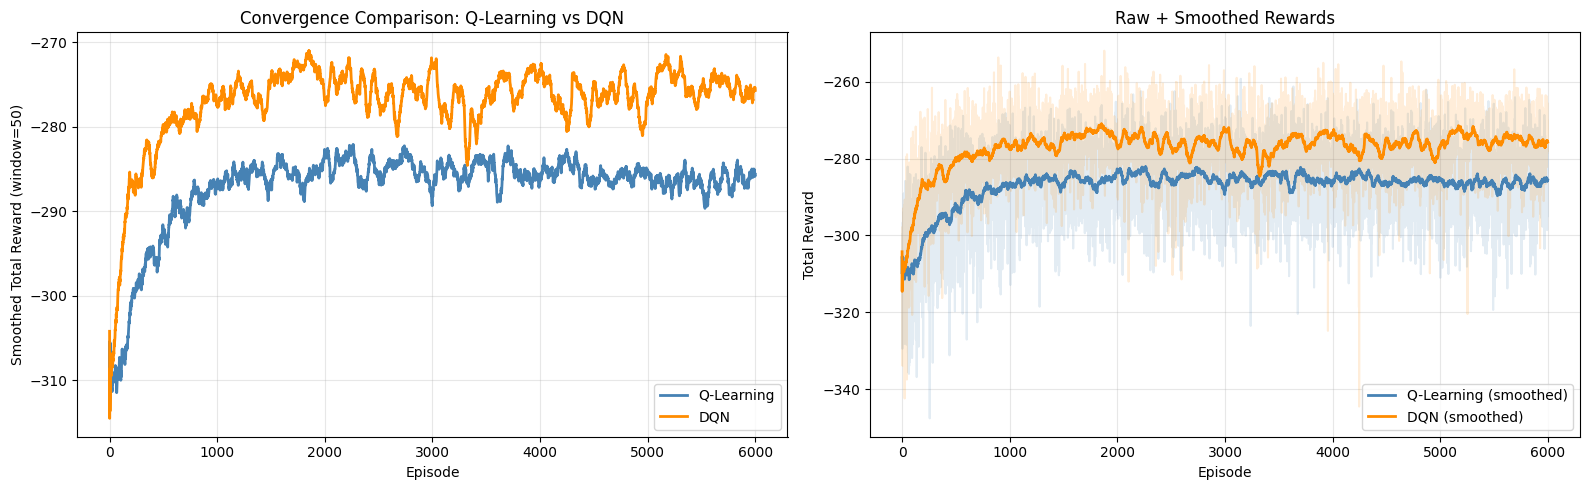


── Final 200-episode averages ──
Q-Learning :  -285.85  (std: 8.51)
DQN        :  -275.70  (std: 6.93)


In [24]:

import matplotlib.pyplot as plt
import numpy as np

def smooth(data, window=50):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

ql_smooth  = smooth(rewards,     window=50)
dqn_smooth = smooth(dqn_rewards, window=50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


ax = axes[0]
ax.plot(ql_smooth,  color='steelblue',  linewidth=2, label='Q-Learning')
ax.plot(dqn_smooth, color='darkorange', linewidth=2, label='DQN')
ax.set_xlabel('Episode')
ax.set_ylabel('Smoothed Total Reward (window=50)')
ax.set_title('Convergence Comparison: Q-Learning vs DQN')
ax.legend()
ax.grid(True, alpha=0.3)


ax2 = axes[1]
ax2.plot(rewards,     alpha=0.15, color='steelblue')
ax2.plot(dqn_rewards, alpha=0.15, color='darkorange')
ax2.plot(ql_smooth,   color='steelblue',  linewidth=2, label='Q-Learning (smoothed)')
ax2.plot(dqn_smooth,  color='darkorange', linewidth=2, label='DQN (smoothed)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Total Reward')
ax2.set_title('Raw + Smoothed Rewards')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_comparison.png', dpi=150)
plt.show()

# --- Summary stats ---
last_n = 200
print(f"\n── Final {last_n}-episode averages ──")
print(f"Q-Learning : {np.mean(rewards[-last_n:]):8.2f}  (std: {np.std(rewards[-last_n:]):.2f})")
print(f"DQN        : {np.mean(dqn_rewards[-last_n:]):8.2f}  (std: {np.std(dqn_rewards[-last_n:]):.2f})")

In [25]:
# ── Cell: Save Models ─────────────────────────────────────────────────────────
import pickle
import torch
import json
import numpy as np
from collections import defaultdict

# Save Q-Learning table
q_table_serializable = {str(k): v for k, v in Q_table.items()}
with open("q_table.json", "w") as f:
    json.dump(q_table_serializable, f)
print("Q-table saved → q_table.json")

# Save DQN model weights
torch.save({
    'policy_net': agent.policy_net.state_dict(),
    'target_net': agent.target_net.state_dict(),
    'epsilon':    agent.epsilon,
}, "dqn_model.pth")
print("DQN model saved → dqn_model.pth")

# Save training rewards for frontend charts
with open("training_stats.json", "w") as f:
    json.dump({"ql_rewards": rewards, "dqn_rewards": dqn_rewards}, f)
print("Training stats saved → training_stats.json")

Q-table saved → q_table.json
DQN model saved → dqn_model.pth
Training stats saved → training_stats.json
